# PREPARACION DE DATOS

En esta fase vamos a crear nuevas variables o transformar las existentes para poder dar mejor respuesta a nuestro objetivo.

Vamos a poner ejemplos tanto de como usar las variables internas como de cómo enriquecer con variables externas.

## SET UP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sqlalchemy as sa
import math

#Automcompletar rápido
%config IPCompleter.greedy=True

pd.options.display.max_columns = None
pd.options.display.max_rows = 400

## CARGA DE DATOS

In [2]:
con = sa.create_engine('sqlite:///../../02_Datos/01_Originales/airbnb2025.db')

cat = pd.read_sql('cat', con = con).drop(columns='index')
num = pd.read_sql('num', con = con).drop(columns='index')

df = pd.merge(cat, num, how='inner', on='id')

In [3]:
df

,id,name,host_response_time,host_is_superhost,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,amenities,has_availability,license,instant_bookable,neighbourhood_group,host_id,host_since,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,precio_m2
0,21853,Bright and airy room,no response,f,"['email', 'phone']",t,t,Cármenes,Private room in rental unit,Private room,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",yes,no,f,Latina,83531,2010-02-21,0.0,0.0,2.0,2.0,40.403810,-3.741300,1,1.0,1.0,1.0,31,4,40,0,0,0,144,33,0,0,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,2,0,2,0,0.27,2772
1,30320,Great Vacational Apartments,no response,f,"['email', 'phone']",t,f,Sol,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""TV with standard cable"", ...",no,no,f,Centro,130907,2010-05-24,0.0,93.0,3.0,6.0,40.414760,-3.704180,2,1.0,1.0,1.0,149,5,180,0,0,0,0,172,0,0,2010-07-06,2022-09-26,4.63,4.71,4.88,4.82,4.78,4.90,4.69,3,3,0,0,0.98,6170
2,30959,Beautiful loft in Madrid Center,no response,f,"['email', 'phone']",t,f,Embajadores,Entire loft,Entire home/apt,"[""Breakfast"", ""Heating"", ""Wifi"", ""Smoking allo...",no,no,f,Centro,132883,2010-05-26,0.0,88.0,1.0,4.0,40.412590,-3.701050,2,1.0,1.0,1.0,92,3,730,0,0,0,0,8,0,0,2015-05-12,2017-05-30,4.38,4.14,4.38,4.63,4.63,4.88,4.25,1,1,0,0,0.07,6170
3,40916,Holiday Apartment Madrid Center,no response,f,"['email', 'phone']",t,f,Universidad,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""Pets allowed"", ""Kitchen"",...",no,no,f,Centro,130907,2010-05-24,0.0,89.0,3.0,6.0,40.422470,-3.705770,3,1.0,1.0,2.0,124,5,180,0,0,0,0,49,0,0,2010-11-01,2021-12-11,4.65,4.69,4.90,4.85,4.79,4.88,4.55,3,3,0,0,0.29,6170
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,within an hour,f,"['email', 'phone']",t,t,Justicia,Private room in rental unit,Private room,"[""Books and reading material"", ""First aid kit""...",yes,no,f,Centro,303845,2010-11-29,100.0,100.0,3.0,3.0,40.418840,-3.696550,4,1.5,1.0,2.0,69,1,30,13,37,59,332,219,44,3,2018-05-10,2024-11-24,4.64,4.78,4.42,4.79,4.85,4.97,4.58,3,1,2,0,2.73,6170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25908,1308811268356474614,Habitación tranquila,within an hour,f,['phone'],t,t,Ventas,Private room in rental unit,Private room,"[""Wifi"", ""TV""]",yes,no,f,Ciudad Lineal,548687839,2023-11-29,100.0,69.0,1.0,2.0,40.429945,-3.653817,2,1.0,1.0,1.0,85,5,15,30,60,90,365,0,0,0,2023-11-29,2023-11-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0,1,0,0.00,3676
25909,1308816654087147793,Vive Madrid Río con Confort y Estilo,within a few hours,f,"['email', 'phone']",t,t,Puerta del Angel,Entire rental unit,Entire home/apt,"[""Wifi"", ""Kitchen"", ""Hot water"", ""Microwave"", ...",yes,no,t,Latina,251333188,2019-03-26,100.0,67.0,163.0,234.0,40.413716,-3.724050,4,1.0,1.0,2.0,258,1,365,15,45,75,350,0,0,0,2019-03-26,2019-03-26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19,19,0,0,0.00,2772
25910,1308818613904246041,Alquilo habitación por 15 días.,no response,f,"['email', 'phone']",t,t,Palacio,Private room in rental unit,Private room,"[""Wifi"", ""Kitchen"", ""TV""]",yes,no,f,Centro,118339834,2017-02-27,0.0,90.0,1.0,1.0,40.413342,-3.

## PREPARACION DE VARIABLES

### Creacion de kpis de palancas

Primero vamos a crear las variables de análisis, es decir las que habíamos identificado como los Kpis que usaremos en las palancas que influyen sobre el negocio.

Habíamos dicho que eran 3:

* precio por noche: esta ya la tenemos directamente en la variable price, pero vamos a revisarla para ver que la entendemos bien
* ocupación: tenemos availability_365 pero hay que transformarla
* precio del inmueble: esta tendremos que crearla con variables externas así que la dejamos para después

**Empezamos con el precio.**

La documentación no aclara si el precio es por todo el inmueble, o si en el caso de que se alquile una habitación es por habitación.

Es un dato clave para poder hacer la valoración de los potenciales ingresos de un inmueble.

Vamos a intentar entenderlo analizando el precio medio por tipo de alquiler.

Es importante filtrar por solo un distrito para no incluir el efecto "zona".

Así que primero elegimos un distrito que tenga muchos datos.

In [4]:
df.neighbourhood_group.value_counts()

neighbourhood_group
Centro                10511
Salamanca              1769
Chamberí               1679
Tetuán                 1619
Arganzuela             1405
Carabanchel             984
Retiro                  963
Ciudad Lineal           962
Chamartín               850
Puente de Vallecas      807
Latina                  699
Moncloa                 692
Usera                   609
San Blas                592
Hortaleza               520
Fuencarral              386
Villaverde              266
Moratalaz               190
Barajas                 185
Villa de Vallecas       137
Vicálvaro                88
Name: count, dtype: int64

In [5]:
df.loc[df.neighbourhood_group == 'Centro',:].groupby('room_type').price.mean()

room_type
Entire home/apt    158.145973
Private room        82.477619
Shared room         67.485714
Name: price, dtype: float64

In [6]:
df.loc[(df.neighbourhood_group == 'Centro')&(df.room_type == 'Shared room')].groupby(['room_type','beds']).price.count()

room_type    beds
Shared room  0.0      3
             1.0     35
             2.0      4
             3.0      3
             4.0      7
             6.0     11
             8.0      6
             12.0     1
Name: price, dtype: int64

In [7]:
df.loc[df.neighbourhood_group == 'Centro'].groupby(['room_type','beds']).price.mean()

room_type        beds
Entire home/apt  0.0      197.529412
                 1.0      114.868148
                 2.0      142.686398
                 3.0      198.986791
                 4.0      232.013559
                 5.0      261.317460
                 6.0      327.135922
                 7.0      348.111111
                 8.0      327.695652
                 9.0      330.272727
                 10.0     354.733333
                 11.0     350.250000
                 12.0    5250.000000
                 13.0     419.000000
                 14.0     481.750000
                 15.0     680.500000
                 16.0     528.000000
                 18.0     606.000000
Private room     0.0       64.714286
                 1.0       78.323799
                 2.0      100.308594
                 3.0      101.976744
                 4.0      203.434783
                 5.0       81.400000
                 6.0       82.250000
                 8.0       74.000000
                

Conclusión:
    
* alquilar el apartamento tiene un precio medio de 158€
* alquilar una habitación tiene un precio medio de 82€ privada o 67€ compartida
* por tanto para calcular los "ingresos" de un inmueble sí deberemos multiplicar el precio el precio por el número de habitaciones cuando sea de los tipos Private room o Shared room

Ahora bien, multiplicar el precio por el total de habitaciones puede sesgar artificialmente al alza la capacidad de generar ingresos de un inmueble. Ya que si se alquila por habitaciones no es probable que siempre esté al 100%. Por tanto, deberíamos ponderarlo por el porcentaje medio de habitaciones alquiladas.

No tenemos ese dato, pero podemos extraerlo de los datos de availability_365 y dejarlo dinámico por si queremos rehacer el cálculo en el futuro

Podemos crear la variable precio total aplicando apply sobre una función personalizada.

In [8]:
1-(df.loc[(df.room_type == 'Shared room')].availability_365.mean()/365)

0.43519872228023837

In [9]:
1-(df.loc[(df.room_type == 'Private room')].availability_365.mean()/365)

0.621896225115096

In [10]:
def crear_precio_total(registro):
    if (registro.beds > 1) & ((registro.room_type == 'Private room')):
        salida = registro.price * registro.beds * 1-(df.loc[(df.room_type == 'Private room')].availability_365.mean()/365)
    elif (registro.beds > 1) & ((registro.room_type == 'Shared room')):
        salida = registro.price * registro.beds * 1-(df.loc[(df.room_type == 'Shared room')].availability_365.mean()/365)
    else:
        salida = registro.price
    return(salida)

df['precio_total'] = round(df.apply(crear_precio_total, axis = 1).astype('float'),2)

Comprobamos

In [11]:
df[['room_type','price','beds','precio_total']].head(30)

,room_type,price,beds,precio_total
0,Private room,31,1.0,31.00
1,Entire home/apt,149,1.0,149.00
2,Entire home/apt,92,1.0,92.00
3,Entire home/apt,124,2.0,124.00
4,Private room,69,2.0,137.62
5,Entire home/apt,98,1.0,98.00
6,Entire home/apt,80,1.0,80.00
7,Entire home/apt,64,2.0,64.00
8,Entire home/apt,159,5.0,159.00
9,Entire home/apt,132,1.0,132.00


**Ahora vamos con la ocupación**

La variable que tenemos que nos permite medir esto es availability_365.

Esta variable nos dice el número de días a un año vista que el inmueble NO está ocupado.

Por tanto nos interesaría transformarla a una medida más directa de ocupación, por ejemplo el % del año que SI está ocupada.

In [12]:
df['ocupacion'] = ((365 - df.availability_365) / 365 * 100).astype('int')
df.head()

,id,name,host_response_time,host_is_superhost,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,amenities,has_availability,license,instant_bookable,neighbourhood_group,host_id,host_since,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,precio_m2,precio_total,ocupacion
0,21853,Bright and airy room,no response,f,"['email', 'phone']",t,t,Cármenes,Private room in rental unit,Private room,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",yes,no,f,Latina,83531,2010-02-21,0.0,0.0,2.0,2.0,40.40381,-3.74130,1,1.0,1.0,1.0,31,4,40,0,0,0,144,33,0,0,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,2,0,2,0,0.27,2772,31.00,60
1,30320,Great Vacational Apartments,no response,f,"['email', 'phone']",t,f,Sol,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""TV with standard cable"", ...",no,no,f,Centro,130907,2010-05-24,0.0,93.0,3.0,6.0,40.41476,-3.70418,2,1.0,1.0,1.0,149,5,180,0,0,0,0,172,0,0,2010-07-06,2022-09-26,4.63,4.71,4.88,4.82,4.78,4.90,4.69,3,3,0,0,0.98,6170,149.00,100
2,30959,Beautiful loft in Madrid Center,no response,f,"['email', 'phone']",t,f,Embajadores,Entire loft,Entire home/apt,"[""Breakfast"", ""Heating"", ""Wifi"", ""Smoking allo...",no,no,f,Centro,132883,2010-05-26,0.0,88.0,1.0,4.0,40.41259,-3.70105,2,1.0,1.0,1.0,92,3,730,0,0,0,0,8,0,0,2015-05-12,2017-05-30,4.38,4.14,4.38,4.63,4.63,4.88,4.25,1,1,0,0,0.07,6170,92.00,100
3,40916,Holiday Apartment Madrid Center,no response,f,"['email', 'phone']",t,f,Universidad,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""Pets allowed"", ""Kitchen"",...",no,no,f,Centro,130907,2010-05-24,0.0,89.0,3.0,6.0,40.42247,-3.70577,3,1.0,1.0,2.0,124,5,180,0,0,0,0,49,0,0,2010-11-01,2021-12-11,4.65,4.69,4.90,4.85,4.79,4.88,4.55,3,3,0,0,0.29,6170,124.00,100
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,within an hour,f,"['email', 'phone']",t,t,Justicia,Private room in rental unit,Private room,"[""Books and reading material"", ""First aid kit""...",yes,no,f,Centro,303845,2010-11-29,100.0,100.0,3.0,3.0,40.41884,-3.69655,4,1.5,1.0,2.0,69,1,30,13,37,59,332,219,44,3,2018-05-10,2024-11-24,4.64,4.78,4.42,4.79,4.85,4.97,4.58,3,1,2,0,2.73,6170,137.62,9


### Transformación de varaibles de análisis

Algunas de las preguntas semilla están dirigidas a comprobar cómo se comporta el precio o la ocupación según otras variables como el número de habitaciones, la media de valoraciones, etc. 

Normalmente podremos hacer mejor estos análisis si discretizamos la variable de análisis. Aplicaremos en:

* Discretización automática:
    * accommodates
    * beds
    * number_of_reviews
    
* Discretización personalizada: 
    * bedrooms

**Discretizar bedrooms**

Comenzamos por evaluar la distribución de los datos.

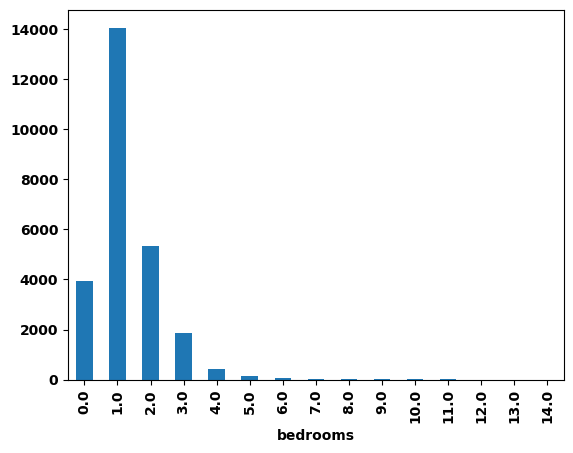

In [13]:
df.bedrooms.value_counts().sort_index().plot.bar();

Vamos a discretizar para 1,2,3 y más de 3.

Podemos usar np.select

In [14]:
condiciones = [df.bedrooms == 0,
               df.bedrooms == 1,
               df.bedrooms == 2,
               df.bedrooms == 3,
               df.bedrooms > 3]

resultados = ['00_Estudio','01_Una','02_Dos','03_Tres','04_Cuatro o mas']

df['bedrooms_disc'] = np.select(condiciones, resultados, default = -999)

Comprobamos

In [15]:
df.bedrooms_disc.sort_index().value_counts()

bedrooms_disc
01_Una             14056
02_Dos              5338
00_Estudio          3935
03_Tres             1876
04_Cuatro o mas      708
Name: count, dtype: int64

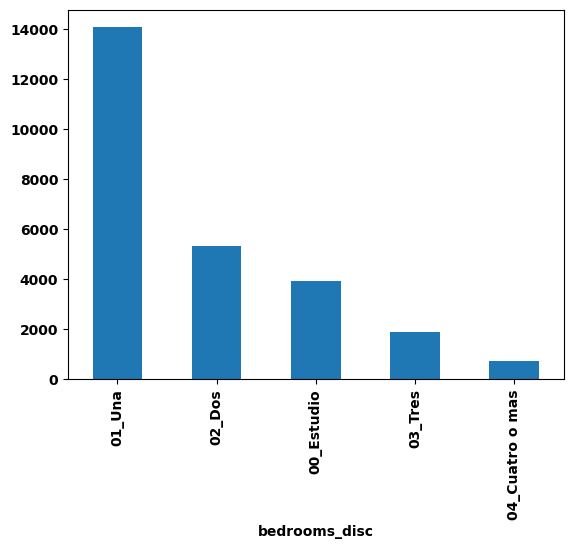

In [16]:
df.bedrooms_disc.sort_index().value_counts().plot.bar();

**Discretizar accommodates, beds y number_of_reviews**

Vamos a usar qcut para discritizar con percentiles 0.5, 0.8, 1

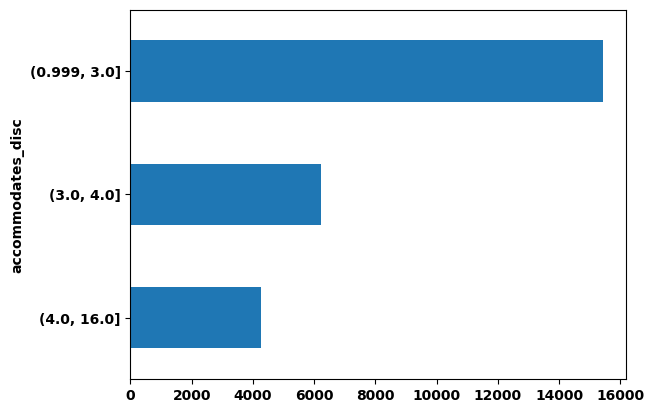

In [17]:
#Generamos la variable discretizada sin labels para saber cuantos accomodates son los que se incluirán en cada grupo
df['accommodates_disc'] = pd.qcut(df.accommodates,[0, 0.5, 0.8, 1])

df['accommodates_disc'].value_counts().sort_index(ascending = False).plot.barh();

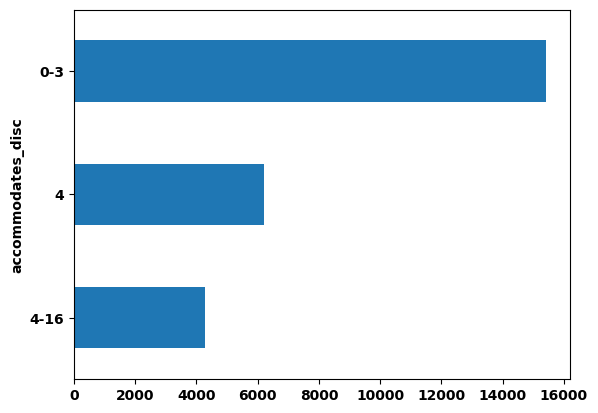

In [18]:
#olvemos a generar la variable con los labels que hemos visto anteriormente
df['accommodates_disc'] = pd.qcut(df.accommodates,[0, 0.5, 0.8, 1],
                                 labels = ['0-3','4','4-16'])

df['accommodates_disc'].value_counts().sort_index(ascending = False).plot.barh();

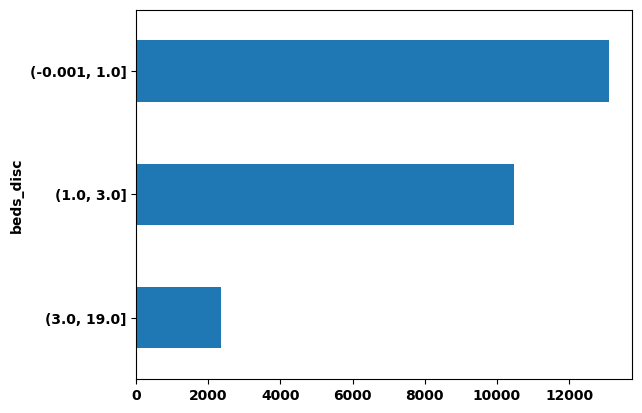

In [19]:
df['beds_disc'] = pd.qcut(df.beds,[0, 0.5, 0.8, 1])

df['beds_disc'].value_counts().sort_index(ascending = False).plot.barh();

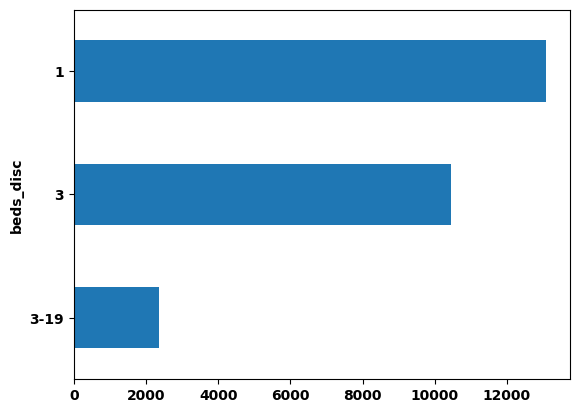

In [20]:
df['beds_disc'] = pd.qcut(df.beds,[0, 0.5, 0.8, 1],
                         labels = ['1','3','3-19'])

df['beds_disc'].value_counts().sort_index(ascending = False).plot.barh();

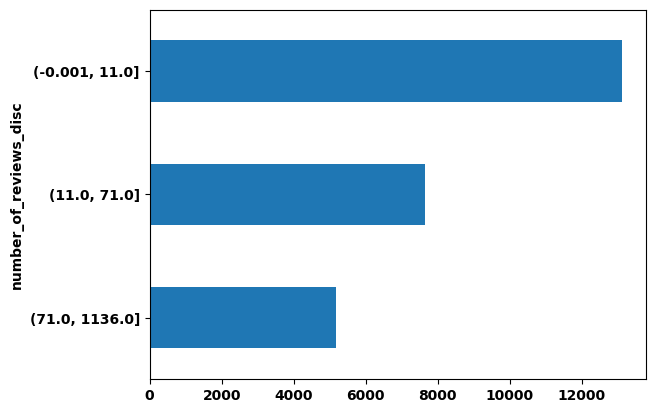

In [21]:
df['number_of_reviews_disc'] = pd.qcut(df.number_of_reviews,[0, 0.5, 0.8, 1])

df['number_of_reviews_disc'].value_counts().sort_index(ascending = False).plot.barh();

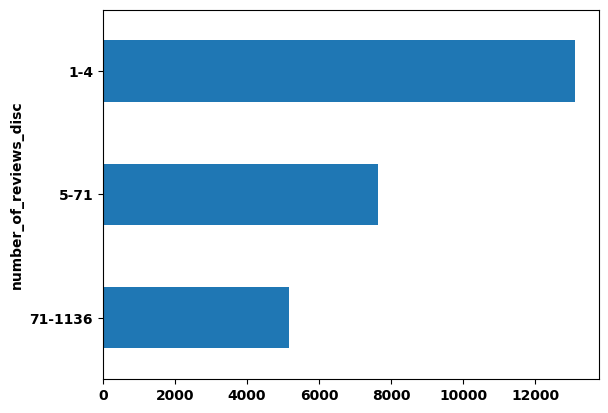

In [22]:
df['number_of_reviews_disc'] = pd.qcut(df.number_of_reviews,[0, 0.5, 0.8, 1],
                                      labels = ['1-4','5-71','71-1136'])

df['number_of_reviews_disc'].value_counts().sort_index(ascending = False).plot.barh();

### Creación de variables con datos externos

Podríamos hacer varias posibilidades con datos externos pero nos centraremos en buscar un precio aproximado del inmueble según la zona y m2

El precio_m2 nos da el precio según el barrio donde este el inmueble y los metros cuadrados los vamos a estimar según el número de habitaciones que tenga, obteniendo el precio total del inmueble de multiplicar ambas variables

No es perfecto, pero nos servirá de aproximación.

**Estimación de los metros cuadrados del inmueble**

Vamos usar el siguiente algoritmo:

* cero habitaciones: m2 = 40
* una habitación: m2 = 50
* dos habitaciones: m2 = 70
* tres habitaciones: m2 = 90
* cuatro habitaciones: m2 = 120
* cinco o más habitaciones: m2 = 150

In [23]:
condiciones = [df.bedrooms == 0,
               df.bedrooms == 1,
               df.bedrooms == 2,
               df.bedrooms == 3,
               df.bedrooms == 4,
               df.bedrooms > 4]

resultados = [40,50,70,90,120,150]

df['m2'] = np.select(condiciones, resultados, default = -999)

Comprobamos

In [24]:
df['m2'].value_counts()

m2
50     14056
70      5338
40      3935
90      1876
120      428
150      280
Name: count, dtype: int64

Ahora ya podemos estimar el precio de compra del inmueble.

Recordamos que al precio que nos sale le quitábamos un 20% por capacidad de negociación.

In [25]:
df['precio_compra'] = df.m2 * df.precio_m2 * 0.8

Comprobamos

In [26]:
df

,id,name,host_response_time,host_is_superhost,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,amenities,has_availability,license,instant_bookable,neighbourhood_group,host_id,host_since,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,precio_m2,precio_total,ocupacion,bedrooms_disc,accommodates_disc,beds_disc,number_of_reviews_disc,m2,precio_compra
0,21853,Bright and airy room,no response,f,"['email', 'phone']",t,t,Cármenes,Private room in rental unit,Private room,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",yes,no,f,Latina,83531,2010-02-21,0.0,0.0,2.0,2.0,40.403810,-3.741300,1,1.0,1.0,1.0,31,4,40,0,0,0,144,33,0,0,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,2,0,2,0,0.27,2772,31.00,60,01_Una,0-3,1,5-71,50,110880.0
1,30320,Great Vacational Apartments,no response,f,"['email', 'phone']",t,f,Sol,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""TV with standard cable"", ...",no,no,f,Centro,130907,2010-05-24,0.0,93.0,3.0,6.0,40.414760,-3.704180,2,1.0,1.0,1.0,149,5,180,0,0,0,0,172,0,0,2010-07-06,2022-09-26,4.63,4.71,4.88,4.82,4.78,4.90,4.69,3,3,0,0,0.98,6170,149.00,100,01_Una,0-3,1,71-1136,50,246800.0
2,30959,Beautiful loft in Madrid Center,no response,f,"['email', 'phone']",t,f,Embajadores,Entire loft,Entire home/apt,"[""Breakfast"", ""Heating"", ""Wifi"", ""Smoking allo...",no,no,f,Centro,132883,2010-05-26,0.0,88.0,1.0,4.0,40.412590,-3.701050,2,1.0,1.0,1.0,92,3,730,0,0,0,0,8,0,0,2015-05-12,2017-05-30,4.38,4.14,4.38,4.63,4.63,4.88,4.25,1,1,0,0,0.07,6170,92.00,100,01_Una,0-3,1,1-4,50,246800.0
3,40916,Holiday Apartment Madrid Center,no response,f,"['email', 'phone']",t,f,Universidad,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""Pets allowed"", ""Kitchen"",...",no,no,f,Centro,130907,2010-05-24,0.0,89.0,3.0,6.0,40.422470,-3.705770,3,1.0,1.0,2.0,124,5,180,0,0,0,0,49,0,0,2010-11-01,2021-12-11,4.65,4.69,4.90,4.85,4.79,4.88,4.55,3,3,0,0,0.29,6170,124.00,100,01_Una,0-3,3,5-71,50,246800.0
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,within an hour,f,"['email', 'phone']",t,t,Justicia,Private room in rental unit,Private room,"[""Books and reading material"", ""First aid kit""...",yes,no,f,Centro,303845,2010-11-29,100.0,100.0,3.0,3.0,40.418840,-3.696550,4,1.5,1.0,2.0,69,1,30,13,37,59,332,219,44,3,2018-05-10,2024-11-24,4.64,4.78,4.42,4.79,4.85,4.97,4.58,3,1,2,0,2.73,6170,137.62,9,01_Una,4,3,71-1136,50,246800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25908,1308811268356474614,Habitación tranquila,within an hour,f,['phone'],t,t,Ventas,Private room in rental unit,Private room,"[""Wifi"", ""TV""]",yes,no,f,Ciudad Lineal,548687839,2023-11-29,100.0,69.0,1.0,2.0,40.429945,-3.653817,2,1.0,1.0,1.0,85,5,15,30,60,90,365,0,0,0,2023-11-29,2023-11-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0,1,0,0.00,3676,85.00,0,01_Una,0-3,1,1-4,50,147040.0
25909,1308816654087147793,Vive Madrid Río con Confort y Estilo,within a few hours,f,"['email', 'phone']",t,t,Puerta del Angel,Entire rental unit,Entire home/apt,"[""Wifi"", ""Kitchen"", ""Hot water"", ""Microwave"", ...",yes,no,t,Latina,251333188,2019-03-26,100.0,67.0,163.0,234.0,40.413716,

In [27]:
df[['bedrooms','m2','neighbourhood_cleansed','precio_m2','precio_compra']].head(20)

,bedrooms,m2,neighbourhood_cleansed,precio_m2,precio_compra
0,1.0,50,Cármenes,2772,110880.0
1,1.0,50,Sol,6170,246800.0
2,1.0,50,Embajadores,6170,246800.0
3,1.0,50,Universidad,6170,246800.0
4,1.0,50,Justicia,6170,246800.0
5,1.0,50,Universidad,6170,246800.0
6,1.0,50,Universidad,6170,246800.0
7,1.0,50,Universidad,6170,246800.0
8,3.0,90,Embajadores,6170,444240.0
9,1.0,50,Recoletos,7846,313840.0


Ahora vamos a poner un ejemplo de qué otro tipo de variables podemos construir.

En este caso podríamos hacer mucho con las coordenadas x,y.

Ya que en turismo la localización es muy importante, vamos a calcular las distancias a la Puerta del Sol como referencia de turismo en Madrid, pero podríamos calcularla a cualquier punto de interés teniendo las coordenadas

Para ello buscamos en Google su longitud y latitud: https://www.123coordenadas.com/coordinates/81497-puerta-del-sol-madrid

* Latitud: 40.4167278
* Longitud: -3.7033387

**Cálculo de la distancia de cada inmueble a la Puerta del Sol**

Dada la curvatura de la tierra la distancia entre dos puntos a partir de su latitud y longitud se calcula con una fórmula que se llama distancia de Haversine.

Una búsqueda en Google nos da una función ya construída para calcularla que podemos adaptar: https://stackoverflow.com/questions/4913349/haversine-formula-in-python-bearing-and-distance-between-two-gps-points

In [28]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):

      R = 6372.8 #En km, si usas millas tienes que cambiarlo por 3959.87433

      dLat = radians(lat2 - lat1)
      dLon = radians(lon2 - lon1)
      lat1 = radians(lat1)
      lat2 = radians(lat2)

      a = sin(dLat/2)**2 + cos(lat1)*cos(lat2)*sin(dLon/2)**2
      c = 2*asin(sqrt(a))

      return R * c

Creamos la variable

In [29]:
#Las coordenadas de la Puerta del Sol serán lat1 y lon1
lat1 = 40.4167278
lon1 = -3.7033387

df['pdi_sol'] = df.apply(lambda registro: haversine(lat1,lon1,registro.latitude,registro.longitude),axis = 1)

Comprobamos revisando la distancia media por distritos.

In [30]:
df.groupby('neighbourhood_cleansed').pdi_sol.mean().sort_values()

neighbourhood_cleansed
Sol                              0.270163
Cortes                           0.549978
Palacio                          0.800952
Embajadores                      0.811362
Justicia                         0.842944
Universidad                      0.880554
Imperial                         1.584499
Argüelles                        1.588717
Acacias                          1.630370
Palos de Moguer                  1.644188
Jerónimos                        1.667782
Recoletos                        1.756636
Trafalgar                        1.765892
Arapiles                         1.941160
Almagro                          2.005605
Casa de Campo                    2.143793
Gaztambide                       2.181128
Delicias                         2.344474
Ibiza                            2.354686
Chopera                          2.364271
Niño Jesús                       2.521784
Puerta del Angel                 2.525976
Castellana                       2.526939
Pacífico   

## Creación de la Target

Consideramos rentable un inmueble si lo podemos rentabilizar en máximo 10 años, por lo que calculamos la target = 1 como aquellos inmuebles cuyo precio_compra/10 < precio_total * ocupacion * 10. Es decir, que si los ingresos anuales de una vivienda son superiores al 10% del valor de la vivienda, es rentable

In [31]:
df['pisos_rentables'] = np.where(df['precio_compra']/10 > df['precio_total'] * df['ocupacion'] * 10, 0, 1)

La target voy a dejarla en el df pero habrá que separarla en el futuro para hacer las predicciones

Cuando vayamos a realizar el proyecto de automation, necesitaremos borrar las columnas relacionadas con la target pero ahora mismo esas columnas son necesarias para el proyecto de discovery, por lo que voy a dejar el código comentado para rescatarlo mas adelante

In [33]:
#df = df.drop(columns=['precio_compra','precio_total','ocupacion'])

In [32]:
df

,id,name,host_response_time,host_is_superhost,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,amenities,has_availability,license,instant_bookable,neighbourhood_group,host_id,host_since,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,precio_m2,precio_total,ocupacion,bedrooms_disc,accommodates_disc,beds_disc,number_of_reviews_disc,m2,precio_compra,pdi_sol,pisos_rentables
0,21853,Bright and airy room,no response,f,"['email', 'phone']",t,t,Cármenes,Private room in rental unit,Private room,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",yes,no,f,Latina,83531,2010-02-21,0.0,0.0,2.0,2.0,40.403810,-3.741300,1,1.0,1.0,1.0,31,4,40,0,0,0,144,33,0,0,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,2,0,2,0,0.27,2772,31.00,60,01_Una,0-3,1,5-71,50,110880.0,3.521406,1
1,30320,Great Vacational Apartments,no response,f,"['email', 'phone']",t,f,Sol,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""TV with standard cable"", ...",no,no,f,Centro,130907,2010-05-24,0.0,93.0,3.0,6.0,40.414760,-3.704180,2,1.0,1.0,1.0,149,5,180,0,0,0,0,172,0,0,2010-07-06,2022-09-26,4.63,4.71,4.88,4.82,4.78,4.90,4.69,3,3,0,0,0.98,6170,149.00,100,01_Una,0-3,1,71-1136,50,246800.0,0.230175,1
2,30959,Beautiful loft in Madrid Center,no response,f,"['email', 'phone']",t,f,Embajadores,Entire loft,Entire home/apt,"[""Breakfast"", ""Heating"", ""Wifi"", ""Smoking allo...",no,no,f,Centro,132883,2010-05-26,0.0,88.0,1.0,4.0,40.412590,-3.701050,2,1.0,1.0,1.0,92,3,730,0,0,0,0,8,0,0,2015-05-12,2017-05-30,4.38,4.14,4.38,4.63,4.63,4.88,4.25,1,1,0,0,0.07,6170,92.00,100,01_Una,0-3,1,1-4,50,246800.0,0.499379,1
3,40916,Holiday Apartment Madrid Center,no response,f,"['email', 'phone']",t,f,Universidad,Entire rental unit,Entire home/apt,"[""Heating"", ""Wifi"", ""Pets allowed"", ""Kitchen"",...",no,no,f,Centro,130907,2010-05-24,0.0,89.0,3.0,6.0,40.422470,-3.705770,3,1.0,1.0,2.0,124,5,180,0,0,0,0,49,0,0,2010-11-01,2021-12-11,4.65,4.69,4.90,4.85,4.79,4.88,4.55,3,3,0,0,0.29,6170,124.00,100,01_Una,0-3,3,5-71,50,246800.0,0.671046,1
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,within an hour,f,"['email', 'phone']",t,t,Justicia,Private room in rental unit,Private room,"[""Books and reading material"", ""First aid kit""...",yes,no,f,Centro,303845,2010-11-29,100.0,100.0,3.0,3.0,40.418840,-3.696550,4,1.5,1.0,2.0,69,1,30,13,37,59,332,219,44,3,2018-05-10,2024-11-24,4.64,4.78,4.42,4.79,4.85,4.97,4.58,3,1,2,0,2.73,6170,137.62,9,01_Una,4,3,71-1136,50,246800.0,0.621024,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25908,1308811268356474614,Habitación tranquila,within an hour,f,['phone'],t,t,Ventas,Private room in rental unit,Private room,"[""Wifi"", ""TV""]",yes,no,f,Ciudad Lineal,548687839,2023-11-29,100.0,69.0,1.0,2.0,40.429945,-3.653817,2,1.0,1.0,1.0,85,5,15,30,60,90,365,0,0,0,2023-11-29,2023-11-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0,1,0,0.00,3676,85.00,0,01_Una,0-3,1,1-4,50,147040.0,4.443394,0
25909,1308816654087147793,Vive Madrid Río con Confort y Estilo,within a few hours,f,"['email', 'phone']",t,t,Puerta del Angel,Entire rental unit,Entire home/apt,"[""Wifi"", ""Kitchen"", ""Hot w

In [ ]:
precio_total = d

## GUARDAMOS EN EL DATAMART

Vamos a guardar esta version como df_preparado

In [33]:
df.to_sql('df_preparado', con = con, if_exists = 'replace')

25913

In [34]:
from sqlalchemy import inspect
insp = inspect(con)
tablas = insp.get_table_names()
tablas

['calendar',
 'cat',
 'df_preparado',
 'listings',
 'listings_det',
 'neigh',
 'num',
 'precio_m2',
 'target']